# Chapter 3: Deep Q-Networks
### **RL: The Seminal Papers** by Rahul Shirale

Welcome to the interactive companion notebook for Chapter 3. We implement the **Deep Q-Network (DQN)** from Mnih et al. (2013, 2015), covering the two innovations that made deep RL stable: **experience replay** and a **target network**. We verify the full pipeline on `CartPole-v1`, which runs in about three minutes on a standard CPU.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rshirale/rl-seminal-papers/blob/main/src/part_2_methods/ch03_dqn/Chapter3_DQN.ipynb)

## 1. Setup
The cell below installs dependencies. In Google Colab, uncomment and run it. Locally, use `make install-full` from the repo root.

In [1]:
# Uncomment in Google Colab:
# Quote each specifier -- the shell would otherwise read > and < as redirection.
# These bounds match requirements.txt / requirements-deep.txt in the repo.
# %pip install "torch>=2.0.0" "gymnasium[classic-control]>=1.0,<2.0" matplotlib pandas

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__} | Gymnasium: {gym.__version__}")

Using device: cpu
PyTorch: 2.2.0 | Gymnasium: 1.0.0


## 2. The Q-Networks

DQN replaces the lookup table from Chapter 2 with a neural network that *generalises* across states. We define two architectures:

- **`DQN`** — three convolutional layers matching the Mnih et al. (2015) specification; used for raw 84×84 Atari frames.
- **`SimpleDQN`** — a two-hidden-layer MLP for vector-based environments like CartPole, where the state is already a compact 4-element vector.

In [3]:
class DQN(nn.Module):
    """CNN Q-network from Mnih et al. (2015). Input: (batch, channels, 84, 84)."""
    def __init__(self, input_channels: int, num_actions: int):
        super(DQN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=8, stride=4),  # 84x84 -> 20x20
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),              # 20x20 -> 9x9
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),              # 9x9  -> 7x7
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, num_actions)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)


class SimpleDQN(nn.Module):
    """MLP Q-network for vector-based environments (e.g. CartPole)."""
    def __init__(self, input_dim: int, num_actions: int):
        super(SimpleDQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_actions)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# Smoke test
cnn_test = DQN(4, 6)(torch.zeros(1, 4, 84, 84))
mlp_test = SimpleDQN(4, 2)(torch.zeros(1, 4))
print(f"DQN output shape:       {cnn_test.shape}  (batch=1, 6 Atari actions)")
print(f"SimpleDQN output shape: {mlp_test.shape}  (batch=1, 2 CartPole actions)")

DQN output shape:       torch.Size([1, 6])  (batch=1, 6 Atari actions)
SimpleDQN output shape: torch.Size([1, 2])  (batch=1, 2 CartPole actions)


## 3. Innovation 1 — Experience Replay

Training on sequential game frames violates gradient descent's i.i.d. assumption — consecutive frames are nearly identical. The **replay buffer** fixes this by storing every transition and sampling *random* mini-batches, breaking temporal correlation.

It also acts as a circular buffer: once full, the oldest transitions are overwritten, keeping memory bounded.

In [4]:
class ReplayBuffer:
    def __init__(self, capacity, state_shape, state_dtype=np.float32):
        shape = (capacity, *state_shape)
        self.capacity = capacity
        self.states = np.zeros(shape, dtype=state_dtype)
        self.next_states = np.zeros(shape, dtype=state_dtype)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.dones = np.zeros(capacity, dtype=np.bool_)
        self.position = 0   # circular write head
        self.size = 0       # number of filled slots

    def push(self, state, action, reward, next_state, done):
        i = self.position
        self.states[i] = state
        self.next_states[i] = next_state
        self.actions[i] = action
        self.rewards[i] = reward
        self.dones[i] = done
        self.position = (i + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        return self._gather(self._random_indices(batch_size))

    def sample_recent(self, batch_size: int):
        # Only the no-replay ablation uses this: the most recent transitions,
        # in order, instead of a random draw. Same batch size, correlated data.
        n = min(batch_size, self.size)
        idx = (self.position - np.arange(n, 0, -1)) % self.capacity
        return self._gather(idx)

    def _random_indices(self, batch_size: int):
        # np.random.choice(..., replace=False) permutes all `size` elements:
        # ~26 ms per call on a 1M-transition buffer, every gradient step.
        # Rejection sampling is O(batch_size) from the same distribution.
        # Small buffers keep the simple call - collisions make resampling
        # unprofitable there, and it still works when batch_size == size.
        if self.size < 100 * batch_size:
            return np.random.choice(self.size, batch_size, replace=False)
        idx = np.random.randint(0, self.size, batch_size)
        while len(np.unique(idx)) < batch_size:
            idx = np.random.randint(0, self.size, batch_size)
        return idx

    def _gather(self, idx):
        return (
            self.states[idx],
            self.actions[idx],
            self.rewards[idx],
            self.next_states[idx],
            self.dones[idx],
        )

    def __len__(self):
        return self.size


# Smoke test
buf = ReplayBuffer(1000, state_shape=(4,))
for _ in range(200):
    buf.push(np.zeros(4), 0, 1.0, np.zeros(4), False)
s, a, r, ns, d = buf.sample(32)
print(f"Buffer size: {len(buf)} | Sampled batch — states: {s.shape}, rewards: {r.shape}")

Buffer size: 200 | Sampled batch — states: (32, 4), rewards: (32,)


## 4. Innovation 2 — Target Network

In naive deep Q-learning the TD target is:

$$y_j = r + \gamma \max_{a'} Q(s', a'; \theta)$$

The same weights $\theta$ appear on both sides — every gradient step shifts the prediction *and* the target simultaneously, creating a moving goalpost that prevents convergence.

DQN's fix: maintain a **frozen copy** of the network $\theta^-$ used only for targets. Every $C$ steps, hard-copy online weights into the target network.

$$y_j = r + \gamma \max_{a'} Q(s', a'; \theta^-)$$

## 5. The DQN Agent

The `DQNAgent` class assembles all components:
- Online network + target network (both `SimpleDQN` for CartPole)
- `ReplayBuffer` for experience storage
- Epsilon-greedy action selection
- Huber loss (`SmoothL1Loss`) for robust gradient updates
- `train_step()` — samples a mini-batch and performs one gradient descent step

In [5]:
class DQNAgent:
    def __init__(self, env, learning_rate=1e-4, gamma=0.99):
        self.env = env
        self.num_actions = env.action_space.n
        self.gamma = gamma
        self.memory = ReplayBuffer(
            capacity=100000,
            state_shape=env.observation_space.shape,
        )

        input_dim = env.observation_space.shape[0]
        self.online_net = SimpleDQN(input_dim, self.num_actions).to(device)
        self.target_net = SimpleDQN(input_dim, self.num_actions).to(device)
        self._update_target_network()       # start with identical weights

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=learning_rate)
        self.huber_loss = nn.SmoothL1Loss()
        self.steps_done = 0

    def select_action(self, state, epsilon):
        if random.random() < epsilon:
            return self.env.action_space.sample()
        with torch.no_grad():
            # torch.as_tensor avoids a copy when the input is already a NumPy
            # array of the right dtype; the legacy torch.FloatTensor always copies.
            state_t = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            return self.online_net(state_t).argmax().item()

    def _update_target_network(self):
        self.target_net.load_state_dict(self.online_net.state_dict())

    def train_step(self, batch_size):
        if len(self.memory) < batch_size:
            return None
        states, actions, rewards, next_states, dones = self.memory.sample(batch_size)

        states      = torch.as_tensor(states, dtype=torch.float32).to(device)
        next_states = torch.as_tensor(next_states, dtype=torch.float32).to(device)
        actions     = torch.as_tensor(actions, dtype=torch.long).to(device)
        rewards     = torch.as_tensor(rewards, dtype=torch.float32).to(device)
        dones       = torch.as_tensor(dones, dtype=torch.bool).to(device)

        current_q = self.online_net(states).gather(1, actions.unsqueeze(1))
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0]
            next_q[dones] = 0.0
            targets = rewards + (self.gamma * next_q)

        loss = self.huber_loss(current_q, targets.unsqueeze(1))
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.steps_done += 1
        return loss.item()

print("DQNAgent defined.")

DQNAgent defined.


## 6. Training on CartPole-v1

We test on `CartPole-v1` rather than Atari — CartPole's 4-element state vector lets us isolate and verify the core DQN algorithm (replay buffer, target network, Huber loss) in about three minutes on a CPU. To switch to Atari, swap `SimpleDQN` for `DQN` and add the frame-stacking wrappers from `train_atari.py`.

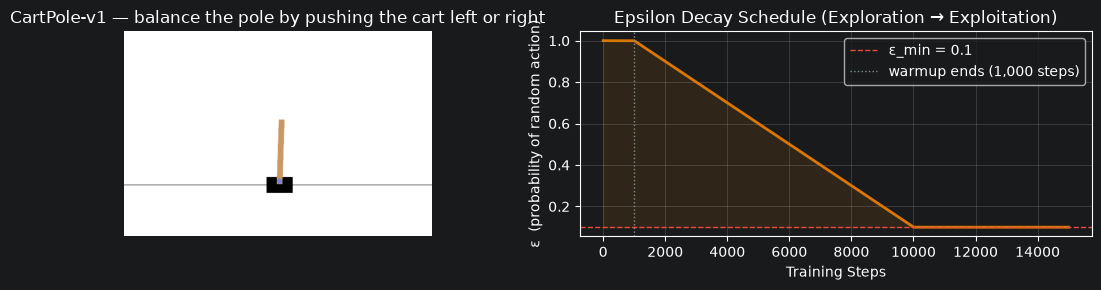

Observation: [cart position, cart velocity, pole angle, pole angular velocity]
Actions:      0 = push left  |  1 = push right


In [6]:
# --- Left: CartPole environment preview ---
env_preview = gym.make("CartPole-v1", render_mode="rgb_array")
env_preview.reset(seed=42)
frame = env_preview.render()
env_preview.close()

# --- Right: Epsilon decay schedule ---
# These must match the training cell below and train_cartpole.py.
EPSILON_START = 1.0
EPSILON_END   = 0.1
EPSILON_DECAY = 10_000
WARMUP_STEPS  = 1_000

steps_range = np.arange(0, 15_000)
eps_curve   = np.where(
    steps_range < WARMUP_STEPS,
    EPSILON_START,                       # held flat: no learning happens yet
    np.maximum(
        EPSILON_END,
        EPSILON_START - (steps_range - WARMUP_STEPS) / EPSILON_DECAY
    )
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))

ax1.imshow(frame)
ax1.axis("off")
ax1.set_title("CartPole-v1 — balance the pole by pushing the cart left or right")

ax2.plot(steps_range, eps_curve, color="#D97706", linewidth=2)
ax2.axhline(EPSILON_END, linestyle="--", color="#e74c3c", linewidth=1,
            label=f"ε_min = {EPSILON_END}")
ax2.axvline(WARMUP_STEPS, linestyle=":", color="#7f8c8d", linewidth=1,
            label=f"warmup ends ({WARMUP_STEPS:,} steps)")
ax2.fill_between(steps_range, eps_curve, EPSILON_END, alpha=0.12, color="#D97706")
ax2.set_title("Epsilon Decay Schedule (Exploration → Exploitation)")
ax2.set_xlabel("Training Steps")
ax2.set_ylabel("ε  (probability of random action)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observation: [cart position, cart velocity, pole angle, pole angular velocity]")
print("Actions:      0 = push left  |  1 = push right")

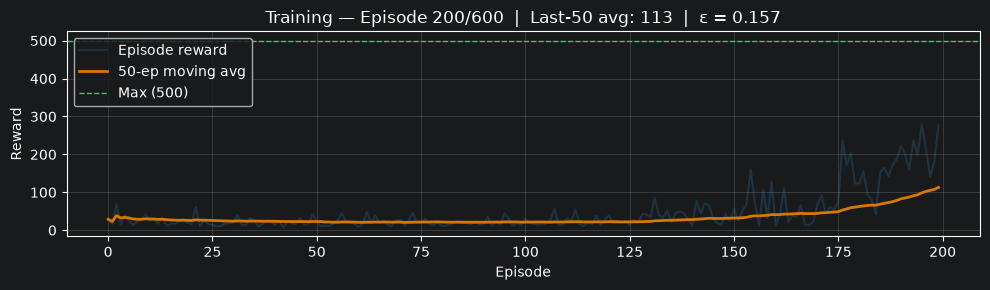

In [ ]:
import os

from IPython.display import clear_output

BATCH_SIZE         = 32
EPSILON_START      = 1.0
EPSILON_END        = 0.1
EPSILON_DECAY      = 10_000
TARGET_UPDATE_FREQ = 500
WARMUP_STEPS       = 1_000
SEED               = 42

# 600 is the figure discussed in the chapter. The environment override exists
# so the automated notebook test can execute this cell in seconds.
NUM_EPISODES       = int(os.environ.get("CH3_NUM_EPISODES", 600))

# Four separate generators feed a single run: `random` for the epsilon-greedy
# coin flip, `np.random` for replay-buffer sampling, `torch` for weight
# initialization, and the environment's own RNG for start states and
# action_space.sample(). Seeding all four is what makes your curve comparable
# to the one printed in the chapter -- miss any one and the run drifts. This
# pins run-to-run variance on one machine; results still differ across
# platforms and PyTorch versions.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

env             = gym.make("CartPole-v1")
env.reset(seed=SEED)        # seeds the episode stream once, not every reset
env.action_space.seed(SEED)

# Built after seeding, so the network's initial weights are covered too.
agent           = DQNAgent(env)
total_steps     = 0
rewards_history = []

for episode in range(NUM_EPISODES):
    state, _ = env.reset()
    episode_reward = 0

    while True:
        # Hold epsilon at 1.0 through warmup. Decaying during warmup would
        # burn the exploration schedule on steps where no learning happens,
        # since train_step() is gated on the same WARMUP_STEPS threshold.
        if total_steps < WARMUP_STEPS:
            epsilon = EPSILON_START
        else:
            epsilon = max(
                EPSILON_END,
                EPSILON_START - (total_steps - WARMUP_STEPS) / EPSILON_DECAY
            )
        action = agent.select_action(state, epsilon)

        next_state, reward, terminated, truncated, _ = env.step(action)
        agent.memory.push(state, action, reward, next_state, terminated)

        state           = next_state
        episode_reward += reward
        total_steps    += 1
        done            = terminated or truncated

        if total_steps >= WARMUP_STEPS:
            agent.train_step(BATCH_SIZE)

        if total_steps % TARGET_UPDATE_FREQ == 0:
            agent._update_target_network()

        if done:
            break

    rewards_history.append(episode_reward)

    if (episode + 1) % 100 == 0:
        clear_output(wait=True)
        avg = np.mean(rewards_history[-50:])

        window = 50
        rolling = [
            np.mean(rewards_history[max(0, i - window + 1): i + 1])
            for i in range(len(rewards_history))
        ]

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(rewards_history, alpha=0.2, color="#3498db", label="Episode reward")
        ax.plot(rolling, linewidth=2, color="#D97706", label="50-ep moving avg")
        ax.axhline(500, linestyle="--", color="#2ecc71", linewidth=1, label="Max (500)")
        ax.set_title(
            f"Training — Episode {episode + 1}/{NUM_EPISODES}"
            f"  |  Last-50 avg: {avg:.0f}"
            f"  |  ε = {epsilon:.3f}"
        )
        ax.set_xlabel("Episode")
        ax.set_ylabel("Reward")
        ax.legend(loc="upper left")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

env.close()
print("Training complete.")

## 7. Learning Curve

The raw reward per episode is noisy. The 50-episode moving average reveals the underlying trend — random exploration early on, then a climb toward the maximum score of 500. Convergence is not perfectly smooth, though: value-based DQN can still dip sharply even after first reaching 500 (localized *catastrophic forgetting*), so expect the curve to wobble near the top rather than lock flat.

In [ ]:
import pandas as pd

rewards_series = pd.Series(rewards_history)
moving_avg     = rewards_series.rolling(50).mean()

plt.figure(figsize=(11, 4))
plt.plot(rewards_series, alpha=0.25, color="#3498db", label="Episode reward")
plt.plot(moving_avg,     linewidth=2, color="#D97706", label="50-episode moving avg")
plt.axhline(500, linestyle="--", color="#2ecc71", linewidth=1, label="Max score (500)")
plt.title("DQN on CartPole-v1", fontsize=13)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_avg = np.mean(rewards_history[-50:])
print(f"Final 50-episode average: {final_avg:.1f} / 500")

## 8. Using the Module Files

In a production setting, import directly from the companion scripts rather than redefining classes in the notebook:

In [ ]:
# If running locally from the ch03_dqn directory:
# from dqn_network import DQN, SimpleDQN
# from replay_buffer import ReplayBuffer
#
# To run the full CartPole experiment from the terminal:
#   python train_cartpole.py
#   make run-ch3-cartpole   (from repo root)
#
# To train on Atari (requires GPU, ~12h):
#   python train_atari.py --env Pong